## Explore MPAS-A data over Puerto Rico

Try **MPAS-Viewer**, which reads remote MPAS datasets from **THREDDS servers** and enables interactive visualization of a **variable-resolution mesh (15–3 km)**. This example focuses on a **3 km-resolution subset over Puerto Rico** during **Hurricane Maria (September 2017)**.

Open the notebook in **Google Colab** and start exploring the data immediately - **No installation on your local machine or data download is required.**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhbravo/mpasviewer/blob/main/examples/18_remote_out_PR.ipynb)

### Data Source

For a more detailed description of the data and its accessibility, you are advised to visit Geoscience Data Exchange (GDEX): 

[![GDEX Dataset](https://img.shields.io/badge/GDEX-Dataset-blue)](https://gdex.ucar.edu/datasets/d010077/)


### THREDDS Data Service

Remote access is provided through the GDEX THREDDS server: 

[![THREDDS Catalog](https://img.shields.io/badge/THREDDS-Catalog-green)](https://tds.gdex.ucar.edu/thredds/catalog/files/d010077/native_diag/catalog.html)

### Step 0 
For Google Colab users, uncomment and run the following cell to install the required packages. If your environment is already set up, you can skip this step and proceed to Step 1.

In [1]:
# %%capture
# !pip install git+https://github.com/jhbravo/earthcmap.git

# !pip install git+https://github.com/jhbravo/mpasviewer.git

# !pip install cartopy netcdf4 s3fs zarr rasterio rioxarray

# !pip uninstall numpy -y
# !pip install "numpy<2.0.0"

### Step 1
Import the required libraries

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime
import matplotlib.pyplot as plt
from earthcmap import escmap
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display, clear_output, HTML
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step 2
Read in data

In [3]:
url_thredds = "https://tds.gdex.ucar.edu/thredds/catalog/files/d010077/native_diag/catalog.html"
inidt = datetime(2017, 9, 20, 0); enddt = datetime(2017, 9, 20, 12)
list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

In [4]:
mpasd = scvtmesh(grid_file = "https://tds.gdex.ucar.edu/thredds/dodsC/files/d010077/native_diag/MAAG.static.nc",
                 diag_list = list_files)

In [5]:
mpasd.dataset(load_variables=['rainnc', 'rainc',"t2m",'olrtoa','refl10cm_max','relhum', 'dewpoint', 'temperature', 'height', 'uzonal', 'umeridional', 'w', 'mslp'])

Loaded grid_file dataset: https://tds.gdex.ucar.edu/thredds/dodsC/files/d010077/native_diag/MAAG.static.nc


In [6]:
mpasd.rain_rate()

In [7]:
dta = mpasd.load()

In [8]:
subd = mpasd.get_subset(dta, lon = (-72.56,-59.17), lat = (12.16,23.49))

### Step 3
Plot animation

In [10]:
var_name = "rain_rate"
level = None
figsize = (8, 8)
cmap = plt.get_cmap('Spectral',100)
norm = None
vmin = 0
vmax = 100
crs = ccrs.PlateCarree()
ntime = subd.sizes["time"]

In [11]:
# Build first collection only to get projection / CRS
first_coll = mpasd.collection(subd, var_name, time_index=0, crs=crs, figsize=figsize, cmap=cmap,norm=None, vmin=vmin, vmax=vmax,)

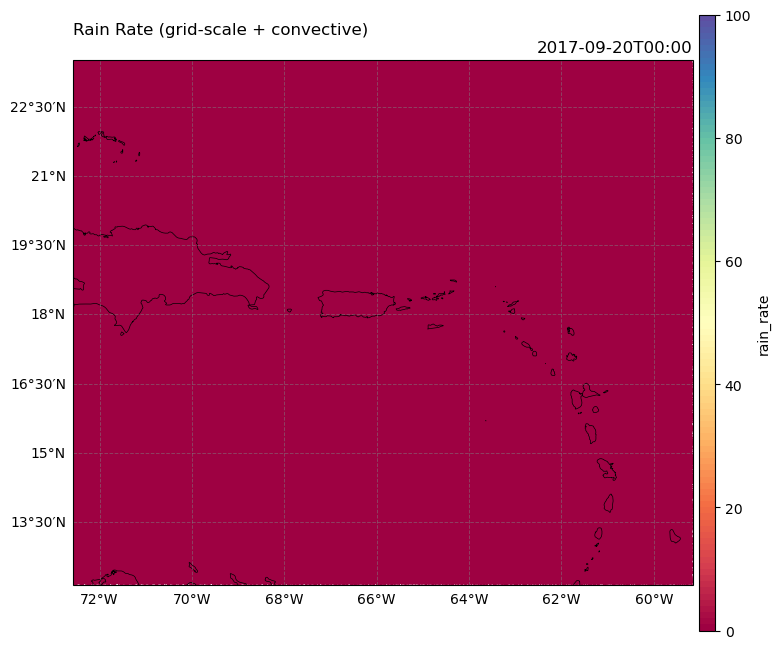

In [12]:
fig, ax = plt.subplots(figsize=figsize,subplot_kw={"projection": first_coll.crs},)

# One persistent colorbar axis
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height,])

current_cbar = None

def draw_frame(i):
    global current_cbar

    ax.clear()
    cbar_ax.clear()

    coll = mpasd.collection(subd,var_name, level=level,time_index=i, crs=crs,figsize=figsize, cmap=cmap,vmin=vmin, vmax=vmax, )

    ax.add_collection(coll)
    ax.autoscale_view()

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{coll.vname}\n", loc="left")
    ax.set_title(f"\n{coll.stime}", loc="right")

    ax.coastlines(linewidth=0.5)

    if coll.limits[1] >= 179.5 and coll.limits[0] <= -179.5:
        ax.set_global()
    else:
        ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color="gray", alpha=0.5, linestyle="--", dms=True,)
    gl.top_labels = False
    gl.right_labels = False

    fig.colorbar(coll, cax=cbar_ax, label=var_name)

    return [coll]

# Draw initial frame
draw_frame(0)

ani = FuncAnimation(fig,draw_frame,frames=ntime,interval=200,blit=False,)

#HTML(ani.to_jshtml())

### Step 4 
Save animation as gif

In [13]:
ani.save("hurricane.gif", writer=PillowWriter(fps=5))

### Step 5

In [14]:
var_name = "t2m"
level = None
figsize = (8, 8)
cmap = plt.get_cmap('Spectral',100)
norm = None
vmin = 270
vmax = 310
crs = ccrs.PlateCarree()
ntime = subd.sizes["time"]

In [15]:
# Build first collection only to get projection / CRS
first_coll = mpasd.collection(subd, var_name, time_index=0, crs=crs, figsize=figsize, cmap=cmap,norm=None, vmin=vmin, vmax=vmax,)

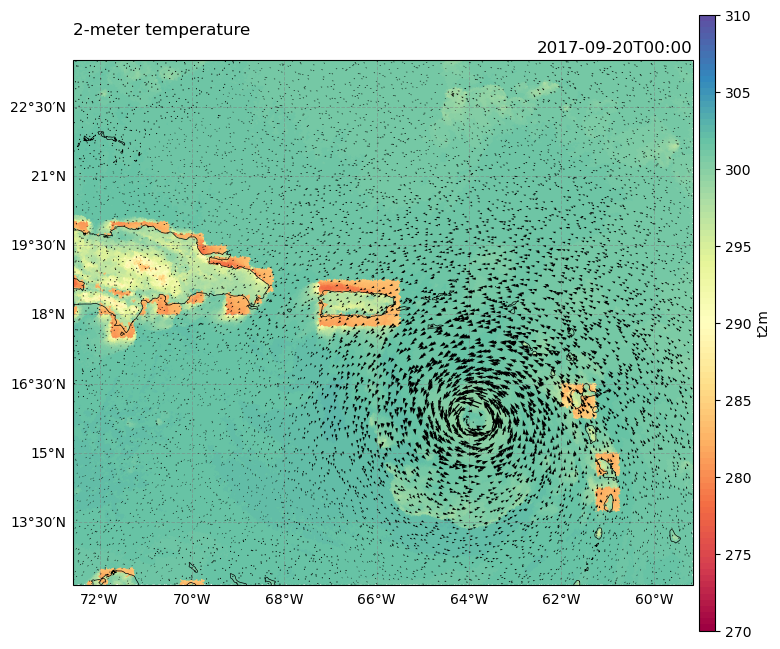

In [16]:
fig, ax = plt.subplots(figsize=figsize,subplot_kw={"projection": first_coll.crs},)

# One persistent colorbar axis
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height,])

current_cbar = None

def draw_frame(i):
    global current_cbar

    ax.clear()
    cbar_ax.clear()

    coll = mpasd.collection(subd,var_name, level=level,time_index=i, crs=crs,figsize=figsize, cmap=cmap,vmin=vmin, vmax=vmax, )

    ax.add_collection(coll)
    ax.autoscale_view()

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{coll.vname}\n", loc="left")
    ax.set_title(f"\n{coll.stime}", loc="right")

    ax.coastlines(linewidth=0.5)

    if coll.limits[1] >= 179.5 and coll.limits[0] <= -179.5:
        ax.set_global()
    else:
        ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

        # --- wind quivers ---
    stride = 25

    lon = subd["face_x"].values
    lat = subd["face_y"].values

    u = subd["uzonal"].isel(time=i, nPresLevels=0).values
    v = subd["umeridional"].isel(time=i, nPresLevels=0).values

    #q = ax.quiver(lon, lat, u, v, transform=ccrs.PlateCarree(), scale=500, width=0.002, zorder=5,)
    q = ax.quiver(lon[::stride], lat[::stride], u[::stride], v[::stride], width=0.002,scale=3000, zorder=5,transform=ccrs.PlateCarree(),)

    #ax.quiverkey(q,X=0.88,Y=-0.08, U=10, label="10 m/s",labelpos="E",)


    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color="gray", alpha=0.5, linestyle="--", dms=True,)
    gl.top_labels = False
    gl.right_labels = False

    fig.colorbar(coll, cax=cbar_ax, label=var_name)

    return [coll]

# Draw initial frame
draw_frame(0)

ani = FuncAnimation(fig,draw_frame,frames=ntime,interval=200,blit=False,)

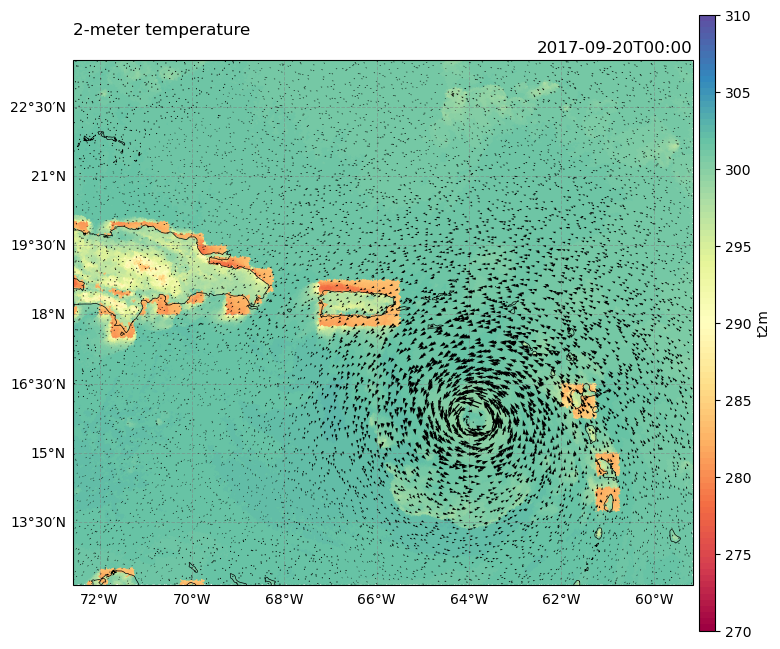

In [17]:
fig, ax = plt.subplots(figsize=figsize,subplot_kw={"projection": first_coll.crs},)

# One persistent colorbar axis
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height,])

current_cbar = None

def draw_frame(i):
    global current_cbar

    ax.clear()
    cbar_ax.clear()

    coll = mpasd.collection(subd,var_name, level=level,time_index=i, crs=crs,figsize=figsize, cmap=cmap,vmin=vmin, vmax=vmax, )

    ax.add_collection(coll)
    ax.autoscale_view()

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{coll.vname}\n", loc="left")
    ax.set_title(f"\n{coll.stime}", loc="right")

    ax.coastlines(linewidth=0.5)

    if coll.limits[1] >= 179.5 and coll.limits[0] <= -179.5:
        ax.set_global()
    else:
        ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

        # --- wind quivers ---
    stride = 25

    lon = subd["face_x"].values
    lat = subd["face_y"].values

    u = subd["uzonal"].isel(time=i, nPresLevels=0).values
    v = subd["umeridional"].isel(time=i, nPresLevels=0).values

    #q = ax.quiver(lon, lat, u, v, transform=ccrs.PlateCarree(), scale=500, width=0.002, zorder=5,)
    q = ax.quiver(lon[::stride], lat[::stride], u[::stride], v[::stride], width=0.002,scale=3000, zorder=5,transform=ccrs.PlateCarree(),)

    #ax.quiverkey(q,X=0.88,Y=-0.08, U=10, label="10 m/s",labelpos="E",)


    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color="gray", alpha=0.5, linestyle="--", dms=True,)
    gl.top_labels = False
    gl.right_labels = False

    fig.colorbar(coll, cax=cbar_ax, label=var_name)

    return [coll]

# Draw initial frame
draw_frame(0)

ani = FuncAnimation(fig,draw_frame,frames=ntime,interval=200,blit=False,)

In [14]:
var_name = "rain_rate"
level = None
figsize = (12, 8)
cmap = plt.get_cmap('Spectral',100)
norm = None
vmin = 0
vmax = 100
crs = ccrs.PlateCarree()
ntime = subd.sizes["time"]

In [15]:
# Build first collection only to get projection / CRS
first_coll = mpasd.collection(subd, var_name, time_index=0, crs=crs, figsize=figsize, cmap=cmap,norm=None, vmin=vmin, vmax=vmax,)

In [ ]:
fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(2, 2)

# Map panel: Cartopy / PlateCarree
ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

# Regular Matplotlib panels
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])


# One persistent colorbar axis
pos = ax0.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.02, pos.y0+0.03, 0.03, pos.height,])

current_cbar = None

def draw_frame(i):
    global current_cbar

    ax0.clear()
    cbar_ax.clear()

    coll = mpasd.collection(subd,var_name, level=level,time_index=i, crs=crs,figsize=figsize, cmap=cmap,vmin=vmin, vmax=vmax, )

    ax0.add_collection(coll)
    ax0.autoscale_view()

    ax0.set_xlabel("Longitude")
    ax0.set_ylabel("Latitude")
    ax0.set_title(f"{coll.vname}\n", loc="left")
    ax0.set_title(f"\n{coll.stime}", loc="right")

    ax0.coastlines(linewidth=0.5)

    if coll.limits[1] >= 179.5 and coll.limits[0] <= -179.5:
        ax0.set_global()
    else:
        ax0.set_extent(coll.limits, crs=ccrs.PlateCarree())

        # --- wind quivers ---
    stride = 25

    lon = subd["face_x"].values
    lat = subd["face_y"].values

    u = subd["uzonal"].isel(time=i, nPresLevels=0).values
    v = subd["umeridional"].isel(time=i, nPresLevels=0).values

    q = ax0.quiver(lon[::stride], lat[::stride], u[::stride], v[::stride], width=0.002,scale=3000, zorder=5,transform=crs,)
    #ax[0][0].quiverkey(q,X=0.88,Y=-0.08, U=10, label="10 m/s",labelpos="E",)

    slp_t = subd['mslp'].isel(time=i)

    center_cell = int(slp_t.argmin(dim="face"))
    
    center_lat = float(subd['face_x'].isel(face=center_cell))
    center_lon = float(subd['face_y'].isel(face=center_cell))
    center_slp = float(slp_t.isel(face=center_cell))

    ax0.scatter(center_lat, center_lon)
    ax0.set_title('')

    gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color="gray", alpha=0.5, linestyle="--", dms=True,)
    gl.top_labels = False
    gl.right_labels = False



    ax1.clear()

    subd['ws'] = (subd['uzonal']**2 + subd['umeridional']**2)**(1/2)
    subd.isel(face=center_cell)['ws'].isel(time=i).plot.line(y='nPresLevels', ax=ax1, yincrease=False)
    ax1.set_title('')
    ax1.set_xlim(0,20)


    ax2.clear()
    subd.isel(face=center_cell)['temperature'].isel(time=i).plot.line(y='nPresLevels', ax=ax2, yincrease=False)
    ax2.set_title('')


    ax3.clear()
    subd.isel(face=center_cell)['relhum'].isel(time=i).plot.line(y='nPresLevels', ax=ax3, yincrease=False)
    ax3.set_title('')
    ax3.set_xlim(0,100)


    fig.colorbar(coll, cax=cbar_ax, label='')

    fig.tight_layout()
    
    return [coll]

# Draw initial frame
draw_frame(0)

ani = FuncAnimation(fig,draw_frame,frames=ntime,interval=200,blit=False,)

HTML(ani.to_jshtml())

In [ ]:
ani.save("hurricane_panels.gif", writer=PillowWriter(fps=5))